In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pickle
import plotly.graph_objs as go
import plotly.express as px
import numpy as np
from scipy.spatial import KDTree
import torch.nn.functional as F
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import plotly.express as px
import plotly.subplots as sp

import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*__floordiv__.*")

In [14]:
def prepare_dataset(idx, model):
    out_dict = {}
    with open(f'../pickle/{model}/{idx}_debug.pickle', 'rb') as f:
        data = pickle.load(f)
    
    if model != 'shape':
        out_dict['src_occ_feats'] = F.normalize(data['src_occ_feats'].unsqueeze(0), p=2, dim=1).cpu().detach()
        out_dict['trg_occ_feats'] = F.normalize(data['trg_occ_feats'].unsqueeze(0), p=2, dim=1).cpu().detach()
    if model != 'occ':
        out_dict['src_shape_feats'] = F.normalize(data['src_shape_feats'].unsqueeze(0), p=2, dim=1).cpu().detach()
        out_dict['trg_shape_feats'] = F.normalize(data['trg_shape_feats'].unsqueeze(0), p=2, dim=1).cpu().detach()
    
    # Load Orientations
    out_dict['src_ori'] = data['src_ori'].cpu().detach().numpy()
    out_dict['trg_ori'] = data['trg_ori'].cpu().detach().numpy()
    out_dict['src_gt_rot'] = data['src_gt_rot'].cpu().detach().numpy()
    out_dict['trg_gt_rot'] = data['trg_gt_rot'].cpu().detach().numpy()
    
    # Load GT corr and Pred. corr
    out_dict['gt_correspondence'] = data['gt_correspondence'].cpu().detach()
    out_dict['pred_corr'] = data['pred_corr'].cpu().detach()
    
    # Load randomly transformed point cloud and translate target pc for better visualization
    out_dict['src_pcd'] = data['src_pcd'].cpu().detach()
    out_dict['trg_pcd'] = data['trg_pcd'].cpu().detach()
    out_dict['src_pcd_raw'] = data['src_pcd_raw'].cpu().detach()
    out_dict['trg_pcd_raw'] = data['trg_pcd_raw'].cpu().detach()
    out_dict['trg_pcd'][:, 2] += 1
    
    return out_dict

def cal_score(out_dict, model):
    if model == 'ours':
        shape_scores = torch.einsum('b c n , b c m -> b n m', out_dict['src_shape_feats'], out_dict['trg_shape_feats'])
        occ_scores = torch.einsum('b c n , b c m -> b n m', out_dict['src_occ_feats'], -out_dict['trg_occ_feats'])
        return shape_scores, occ_scores
    if model == 'shape':
        shape_scores = torch.einsum('b c n , b c m -> b n m', out_dict['src_shape_feats'], out_dict['trg_shape_feats'])
        return shape_scores
    if model == 'occ':
        occ_scores = torch.einsum('b c n , b c m -> b n m', out_dict['src_occ_feats'], -out_dict['trg_occ_feats'])
        return occ_scores

In [25]:
idx = 77
ours_dict = prepare_dataset(idx, 'ours')
shape_dict = prepare_dataset(idx, 'shape')
occ_dict = prepare_dataset(idx, 'occ')

ours_shape_scores, ours_occ_scores = cal_score(ours_dict, 'ours')
shape_shape_scores = cal_score(ours_dict, 'shape')
occ_occ_scores = cal_score(ours_dict, 'occ')

In [26]:
random_s, random_t = ours_dict['gt_correspondence'][torch.randint(0, ours_dict['gt_correspondence'].size(0), (1,))][0]
random_s, random_t = random_s.item(), random_t.item()
selected_src_point = ours_dict['src_pcd'][random_s]
selected_trg_point = ours_dict['trg_pcd'][random_t]

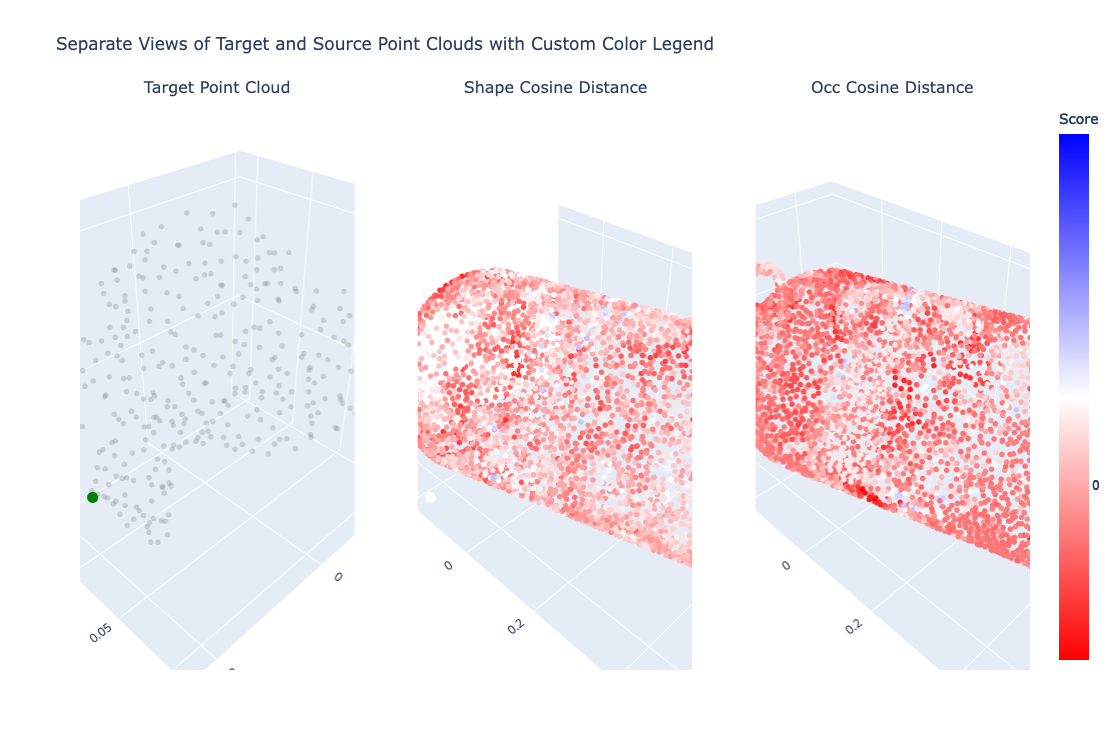

In [27]:
selected_shape_scores = ours_shape_scores[0, :, random_t].numpy()
shape_color_scale = (selected_shape_scores + 1) / 2
selected_occ_scores = ours_occ_scores[0, :, random_t].numpy()
occ_color_scale = (selected_occ_scores + 1) / 2
custom_colorscale = [[0, 'red'], [0.5, 'white'], [1, 'blue']]

# Create a subplot figure with two plots side by side
fig = sp.make_subplots(rows=1, cols=3, subplot_titles=("Target Point Cloud", "Shape Cosine Distance", "Occ Cosine Distance"),
                       specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}, {'type': 'scatter3d'}]])

# Plot target point cloud (trg_pcd) in semi-transparent blue in the first subplot
fig.add_trace(go.Scatter3d(
    x=ours_dict['trg_pcd'][:, 0].numpy(),
    y=ours_dict['trg_pcd'][:, 1].numpy(),
    z=ours_dict['trg_pcd'][:, 2].numpy(),
    mode='markers',
    marker=dict(size=2, color='gray', opacity=0.3),
    name="Target Point Cloud"
), row=1, col=1)

# Highlight selected target point in opaque green in the first subplot
fig.add_trace(go.Scatter3d(
    x=[selected_trg_point[0].item()],
    y=[selected_trg_point[1].item()],
    z=[selected_trg_point[2].item()],
    mode='markers',
    marker=dict(size=4, color='green', opacity=1.0),
    name="Selected Target Point"
), row=1, col=1)

# Highlight selected target point in opaque green in the first subplot
fig.add_trace(go.Scatter3d(
    x=[selected_src_point[0].item()],
    y=[selected_src_point[1].item()],
    z=[selected_src_point[2].item()],
    mode='markers',
    marker=dict(size=4, color='green', opacity=1.0),
    name="Selected Source Point"
), row=1, col=2)
# Highlight selected target point in opaque green in the first subplot
fig.add_trace(go.Scatter3d(
    x=[selected_src_point[0].item()],
    y=[selected_src_point[1].item()],
    z=[selected_src_point[2].item()],
    mode='markers',
    marker=dict(size=4, color='green', opacity=1.0),
    name="Selected Source Point"
), row=1, col=3)

# Plot source point cloud (src_pcd) with interpolated color based on scores in the second subplot
fig.add_trace(go.Scatter3d(
    x=ours_dict['src_pcd'][:, 0].numpy(),
    y=ours_dict['src_pcd'][:, 1].numpy(),
    z=ours_dict['src_pcd'][:, 2].numpy(),
    mode='markers',
    marker=dict(size=2, color=shape_color_scale, colorscale=custom_colorscale, 
                colorbar=dict(title="Score", tickvals=[0, 0.5, 1], ticktext=['-1', '0', '1'])),
    name="Source Point Cloud (Interpolated Scores)"
), row=1, col=2)

# Plot source point cloud (src_pcd) with interpolated color based on scores in the second subplot
fig.add_trace(go.Scatter3d(
    x=ours_dict['src_pcd'][:, 0].numpy(),
    y=ours_dict['src_pcd'][:, 1].numpy(),
    z=ours_dict['src_pcd'][:, 2].numpy(),
    mode='markers',
    marker=dict(size=2, color=occ_color_scale, colorscale=custom_colorscale, 
                colorbar=dict(title="Score", tickvals=[0, 0.5, 1], ticktext=['-1', '0', '1'])),
    name="Source Point Cloud (Interpolated Scores)"
), row=1, col=3)

# Set layout for better visualization
fig.update_layout(title="Separate Views of Target and Source Point Clouds with Custom Color Legend", showlegend=False)

# Resize layout and show
fig.update_layout(width=1000, height=750)
fig.show()

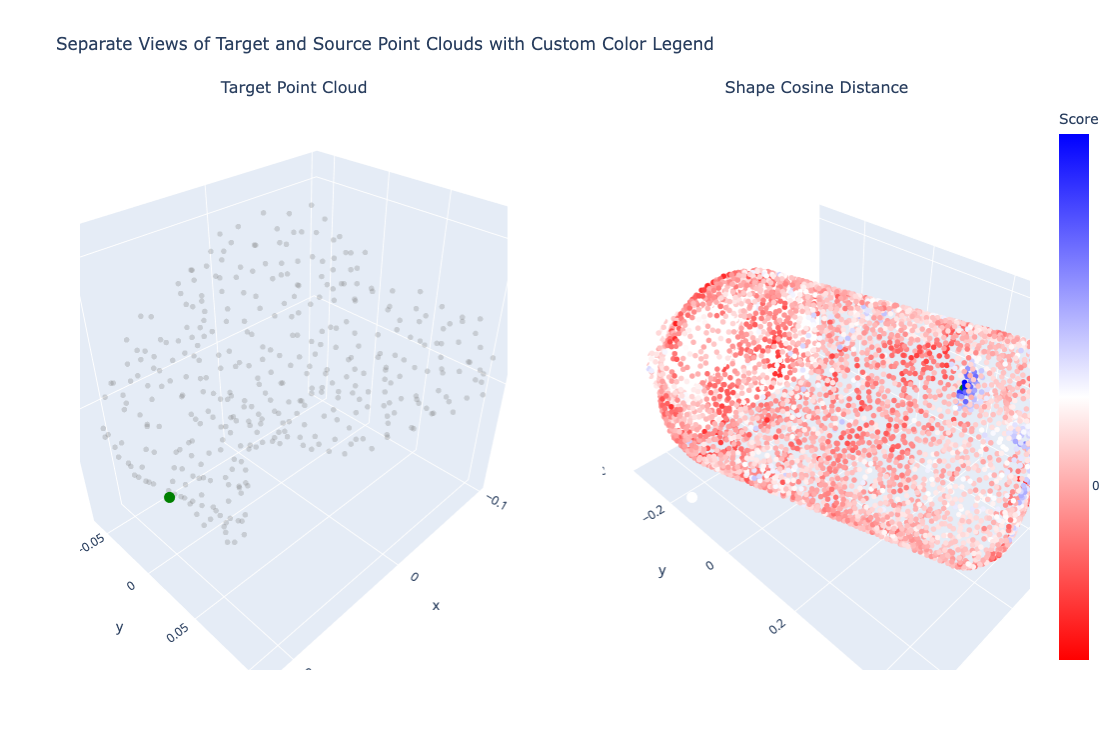

In [28]:
selected_shape_scores = shape_shape_scores[0, :, random_t].numpy()
shape_color_scale = (selected_shape_scores + 1) / 2
custom_colorscale = [[0, 'red'], [0.5, 'white'], [1, 'blue']]

# Create a subplot figure with two plots side by side
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=("Target Point Cloud", "Shape Cosine Distance"),
                       specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]])

# Plot target point cloud (trg_pcd) in semi-transparent blue in the first subplot
fig.add_trace(go.Scatter3d(
    x=ours_dict['trg_pcd'][:, 0].numpy(),
    y=ours_dict['trg_pcd'][:, 1].numpy(),
    z=ours_dict['trg_pcd'][:, 2].numpy(),
    mode='markers',
    marker=dict(size=2, color='gray', opacity=0.3),
    name="Target Point Cloud"
), row=1, col=1)

# Highlight selected target point in opaque green in the first subplot
fig.add_trace(go.Scatter3d(
    x=[selected_trg_point[0].item()],
    y=[selected_trg_point[1].item()],
    z=[selected_trg_point[2].item()],
    mode='markers',
    marker=dict(size=4, color='green', opacity=1.0),
    name="Selected Target Point"
), row=1, col=1)

# Highlight selected target point in opaque green in the first subplot
fig.add_trace(go.Scatter3d(
    x=[selected_src_point[0].item()],
    y=[selected_src_point[1].item()],
    z=[selected_src_point[2].item()],
    mode='markers',
    marker=dict(size=4, color='green', opacity=1.0),
    name="Selected Source Point"
), row=1, col=2)

# Plot source point cloud (src_pcd) with interpolated color based on scores in the second subplot
fig.add_trace(go.Scatter3d(
    x=ours_dict['src_pcd'][:, 0].numpy(),
    y=ours_dict['src_pcd'][:, 1].numpy(),
    z=ours_dict['src_pcd'][:, 2].numpy(),
    mode='markers',
    marker=dict(size=2, color=shape_color_scale, colorscale=custom_colorscale, 
                colorbar=dict(title="Score", tickvals=[0, 0.5, 1], ticktext=['-1', '0', '1'])),
    name="Source Point Cloud (Interpolated Scores)"
), row=1, col=2)

# Set layout for better visualization
fig.update_layout(title="Separate Views of Target and Source Point Clouds with Custom Color Legend", showlegend=False)

# Resize layout and show
fig.update_layout(width=1000, height=750)
fig.show()

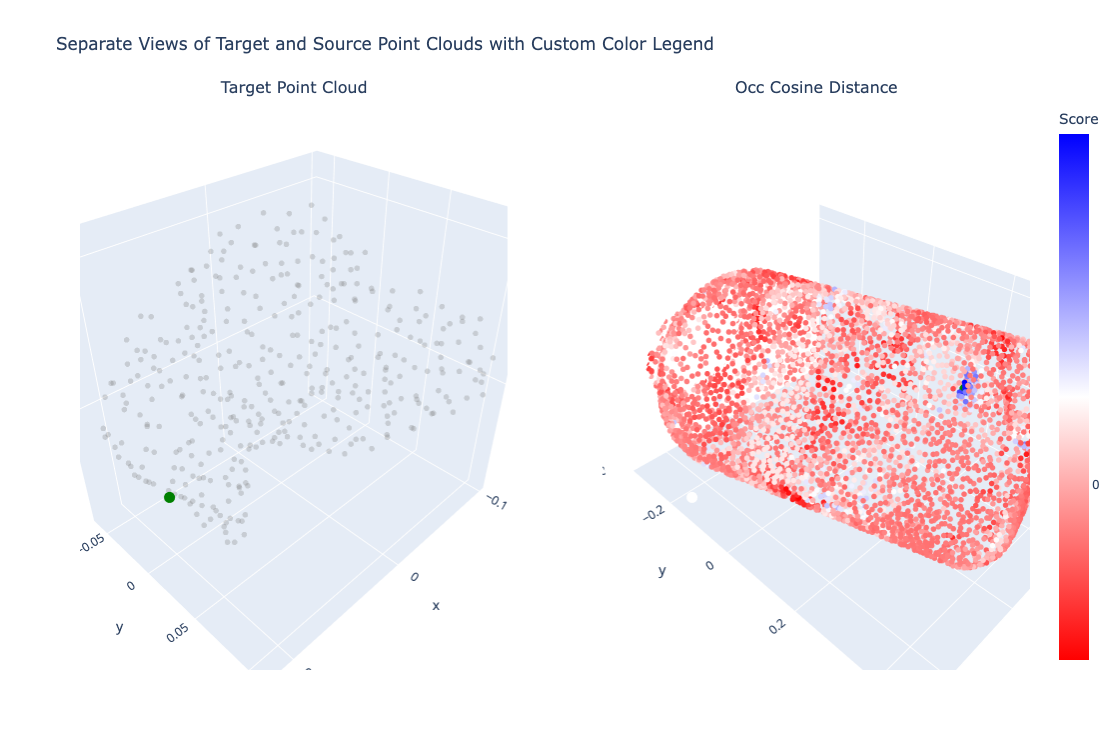

In [29]:
selected_occ_scores = ours_occ_scores[0, :, random_t].numpy()
occ_color_scale = (selected_occ_scores + 1) / 2
custom_colorscale = [[0, 'red'], [0.5, 'white'], [1, 'blue']]

# Create a subplot figure with two plots side by side
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=("Target Point Cloud", "Occ Cosine Distance"),
                       specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]])

# Plot target point cloud (trg_pcd) in semi-transparent blue in the first subplot
fig.add_trace(go.Scatter3d(
    x=ours_dict['trg_pcd'][:, 0].numpy(),
    y=ours_dict['trg_pcd'][:, 1].numpy(),
    z=ours_dict['trg_pcd'][:, 2].numpy(),
    mode='markers',
    marker=dict(size=2, color='gray', opacity=0.3),
    name="Target Point Cloud"
), row=1, col=1)

# Highlight selected target point in opaque green in the first subplot
fig.add_trace(go.Scatter3d(
    x=[selected_trg_point[0].item()],
    y=[selected_trg_point[1].item()],
    z=[selected_trg_point[2].item()],
    mode='markers',
    marker=dict(size=4, color='green', opacity=1.0),
    name="Selected Target Point"
), row=1, col=1)

# Highlight selected target point in opaque green in the first subplot
fig.add_trace(go.Scatter3d(
    x=[selected_src_point[0].item()],
    y=[selected_src_point[1].item()],
    z=[selected_src_point[2].item()],
    mode='markers',
    marker=dict(size=4, color='green', opacity=1.0),
    name="Selected Source Point"
), row=1, col=2)

# Plot source point cloud (src_pcd) with interpolated color based on scores in the second subplot
fig.add_trace(go.Scatter3d(
    x=ours_dict['src_pcd'][:, 0].numpy(),
    y=ours_dict['src_pcd'][:, 1].numpy(),
    z=ours_dict['src_pcd'][:, 2].numpy(),
    mode='markers',
    marker=dict(size=2, color=occ_color_scale, colorscale=custom_colorscale, 
                colorbar=dict(title="Score", tickvals=[0, 0.5, 1], ticktext=['-1', '0', '1'])),
    name="Source Point Cloud (Interpolated Scores)"
), row=1, col=2)

# Set layout for better visualization
fig.update_layout(title="Separate Views of Target and Source Point Clouds with Custom Color Legend", showlegend=False)

# Resize layout and show
fig.update_layout(width=1000, height=750)
fig.show()